In [1]:
import sys, os
import numpy as np
import xarray as xr

import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.append(os.path.abspath("../spectral-spatial-sst-model"))
from explanatory_variables import reconstruct_predictors
from response_variable import gam_fit, seasonal_decompose

In [2]:
dataset_path = "E:/dataset"
gam_predictors_ds = xr.open_dataset(f"{dataset_path}/mx_secihti_cicese_eval_sst_gam_predictors_nep_0p10deg_200501-202508_v1.nc")
gam_predictors_ds = gam_predictors_ds.sel(lat=slice(20, 35), lon=slice(-125, -105))
gam_predictors_ds

predictors_spectral_modes_files = {
	"adt": "mx_secihti_cicese_spectral_modes_adt_nep_0p083deg_v1.nc",
	"t2m": "mx_secihti_cicese_spectral_modes_t2m_nep_0p25deg_v1.nc",
	"u10": "mx_secihti_cicese_spectral_modes_u10_nep_0p25deg_v1.nc",
	"v10": "mx_secihti_cicese_spectral_modes_v10_nep_0p25deg_v1.nc",
	"pdo": "mx_secihti_cicese_spectral_modes_pdo_v1.nc",
	"noi": "mx_secihti_cicese_spectral_modes_noi_v1.nc",
	"np": "mx_secihti_cicese_spectral_modes_np_v1.nc",
	"oni": "mx_secihti_cicese_spectral_modes_oni_v1.nc",
}

predictors_modes = {
	name: xr.open_dataset(f"{dataset_path}/{file}") 
		for name, file in predictors_spectral_modes_files.items()
}

sst_ds = xr.open_dataset(f"{dataset_path}/mursst.nc")
sst_ds = sst_ds.sel(latitude=slice(20, 35), longitude=slice(-125, -105))
sst_ds = sst_ds.rename({"longitude": "lon", "latitude": "lat"})

X_ds = reconstruct_predictors(
	gam_predictors_ds, 
	predictors_modes, 
	sst_ds.time.values
)

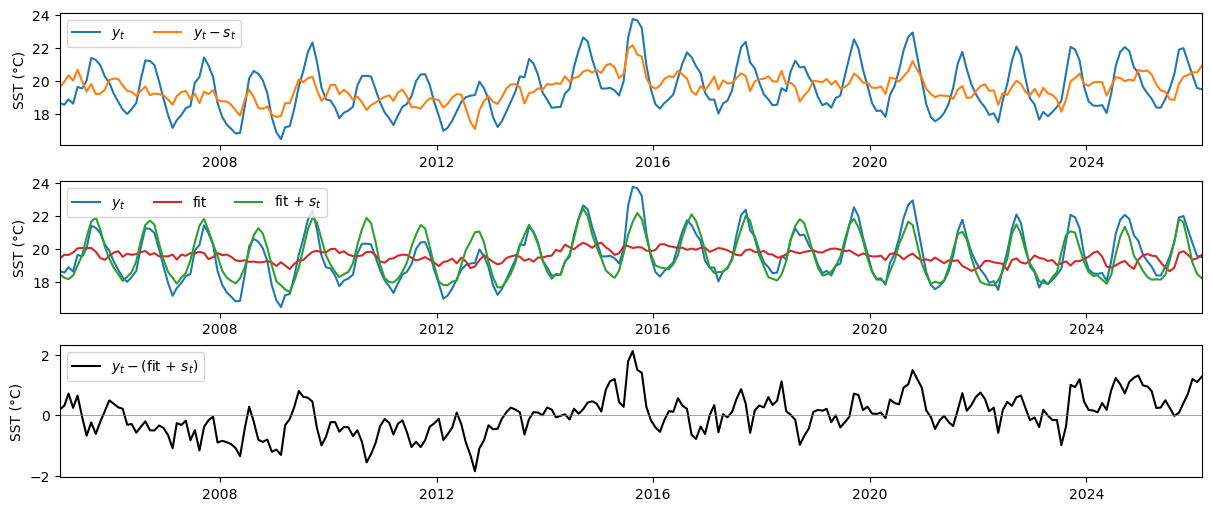

In [3]:
point = [-124.25,27.1666666667]
ilon = np.abs(X_ds.lon - point[0]).argmin()
ilat = np.abs(X_ds.lat - point[1]).argmin()
j = np.abs(sst_ds.lon - point[0]).argmin()
i = np.abs(sst_ds.lat - point[1]).argmin()

activos_mask = gam_predictors_ds.to_array().values[:, 0, ilat, ilon] == 1
pred_idx = np.where(activos_mask)[0]

X_pixel = X_ds.predictor_signal.values[:, pred_idx, ilat, ilon]
y_pixel = sst_ds.sst.values[:, i, j]

seasonal, _ = seasonal_decompose(y_pixel)
y_pixel = y_pixel - seasonal
prediction = gam_fit(X_pixel, y_pixel)

fig = plt.figure(figsize=(12, 5), constrained_layout=True) 

ax = fig.add_subplot(3, 1, 1)
ax.plot(sst_ds.time, sst_ds.sst[:, i, j], c="tab:blue", label=r"$y_t$")
ax.plot(sst_ds.time, sst_ds.sst[:, i, j] - seasonal, c="tab:orange", label="$y_t - s_t$")
ax.set_xlim(sst_ds.time[0], sst_ds.time[-1])
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left", ncol=2)

ax = fig.add_subplot(3, 1, 2)
ax.plot(sst_ds.time, sst_ds.sst[:, i, j], c="tab:blue", label=r"$y_t$")
ax.plot(sst_ds.time, prediction, c="tab:red", label="fit")
ax.plot(sst_ds.time, prediction + seasonal, c="tab:green", label=r"fit + $s_t$")
ax.set_xlim(sst_ds.time[0], sst_ds.time[-1])
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left", ncol=3)

ax = fig.add_subplot(3, 1, 3)
ax.plot(sst_ds.time, sst_ds.sst[:, i, j] - (prediction + seasonal), c="k", label=r"$y_t - $(fit + $s_t$)")
ax.set_xlim(sst_ds.time[0], sst_ds.time[-1])
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left", ncol=3)
ax.axhline(y=0, color='grey', lw=0.5)
plt.show()

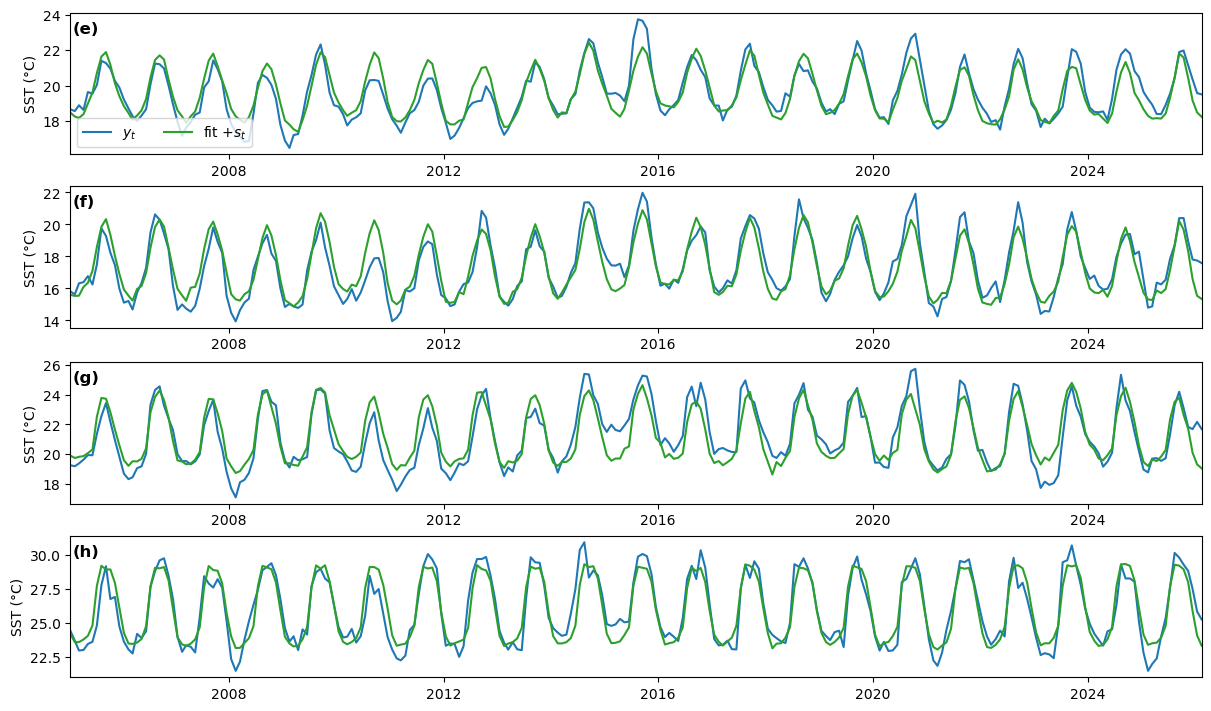

In [4]:
points = [[-124.25,27.1666666667], [-119,31.5], [-116.5,24.3333333333], [-108.75,21.5]]
locations = list("efgh")

fig = plt.figure(figsize=(12, 7), constrained_layout=True) 

for k in range(len(points)):
    point = points[k]
    ilon = np.abs(X_ds.lon - point[0]).argmin()
    ilat = np.abs(X_ds.lat - point[1]).argmin()
    j = np.abs(sst_ds.lon - point[0]).argmin()
    i = np.abs(sst_ds.lat - point[1]).argmin()

    activos_mask = gam_predictors_ds.to_array().values[:, 0, ilat, ilon] == 1
    pred_idx = np.where(activos_mask)[0]

    X_pixel = X_ds.predictor_signal.values[:, pred_idx, ilat, ilon]
    y_pixel = sst_ds.sst.values[:, i, j]

    seasonal, _ = seasonal_decompose(y_pixel)
    y_pixel = y_pixel - seasonal
    serie = gam_fit(X_pixel, y_pixel)

    ax = fig.add_subplot(len(points), 1, k+1)
    ax.plot(sst_ds.time, sst_ds.sst[:, i, j], c="tab:blue", label=r"$y_t$")
    ax.plot(sst_ds.time, serie + seasonal, c="tab:green", label=r"fit $+ s_t$")
    ax.set_xlim(sst_ds.time[0], sst_ds.time[-1])
    ax.set_ylabel("SST (°C)")
    ax.text(0.0025,0.89, f"({locations[k]})", fontsize=12, fontweight='bold', color='black', ha='left', va='center', transform=ax.transAxes)

    if k == 0: ax.legend(loc="lower left", ncol=2)
plt.show()